# Projet — Visualisation & EDA Dataset Enrichi

Objectif : comprendre les relations entre les features et la variable cible `prix_cup`.

**Dataset** : `fruits_legumes_enrichi.csv` — 710 lignes, 24 colonnes, 5 années

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ROUGE = '#C0392B'
BLEU  = '#3498DB'
VERT  = '#2ECC71'

df = pd.read_csv('fruits_legumes_enrichi.csv', sep=';', encoding='utf-8')
print(f'Dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes')
df.head(3)

Dataset : 710 lignes x 24 colonnes


,produit,forme,prix_detail,rendement,taille_cup,prix_cup,categorie,annee,forme_encoded,categorie_encoded,...,jours_gel,jours_chaleur,precip_totale,prix_diesel,prix_electricite,urea,dap,tsp,mop,prix_bls
0,Watermelon,Fresh,0.3334,0.520000,0.330693,0.2120,fruit,2013,0,1,...,6.0,1.0,511.2,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
1,Turnip greens,Frozen,1.4730,0.776027,0.352740,0.6696,legume,2013,2,0,...,6.0,74.0,142.1,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
2,Turnip greens,Fresh,2.4717,0.750000,0.319670,1.0535,legume,2013,0,0,...,6.0,74.0,142.1,4.2421,14.3,304.0,474.0,390.0,355.0,1.536


---
## 1. Distribution de la variable cible

**Interprétation** : La distribution est asymétrique à droite — la majorité des produits
coûtent entre 0.20$ et 1.50 dollars par cup. Quelques outliers dépassent 2.50 dollars (cerises, framboises).
Cela signifie que le modèle devra bien gérer ces valeurs extrêmes.

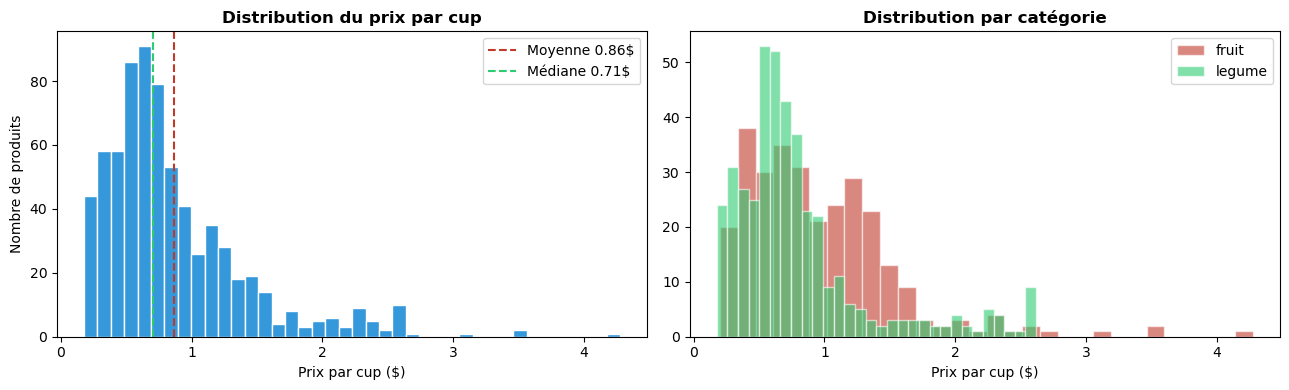

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution globale
axes[0].hist(df['prix_cup'], bins=40, color=BLEU, edgecolor='white')
axes[0].axvline(df['prix_cup'].mean(),   color=ROUGE, linestyle='--',
                lw=1.5, label=f'Moyenne {df["prix_cup"].mean():.2f}$')
axes[0].axvline(df['prix_cup'].median(), color=VERT, linestyle='--',
                lw=1.5, label=f'Médiane {df["prix_cup"].median():.2f}$')
axes[0].set_title('Distribution du prix par cup', fontweight='bold')
axes[0].set_xlabel('Prix par cup ($)')
axes[0].set_ylabel('Nombre de produits')
axes[0].legend()

# Distribution par catégorie
for cat, couleur in [('fruit', ROUGE), ('legume', VERT)]:
    axes[1].hist(df[df['categorie'] == cat]['prix_cup'],
                 bins=30, alpha=0.6, color=couleur, label=cat, edgecolor='white')
axes[1].set_title('Distribution par catégorie', fontweight='bold')
axes[1].set_xlabel('Prix par cup ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 2. Corrélation avec la variable cible

**Interprétation** : `prix_detail` est de loin la feature la plus corrélée avec `prix_cup` (0.64).
Le `rendement` est négativement corrélé (-0.28) — un bon rendement signifie moins de déchets
donc un coût par portion plus faible. Les variables météo et énergie ont une corrélation faible
mais elles apportent du contexte géographique utile pour le modèle non-linéaire.

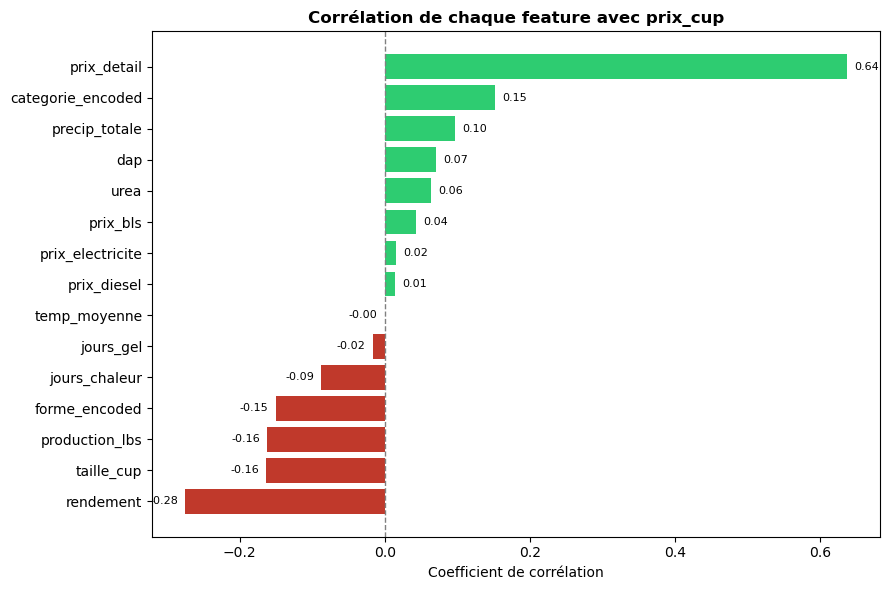

In [3]:
# Colonnes numériques pour la corrélation
cols_num = ['prix_detail', 'rendement', 'taille_cup', 'forme_encoded',
            'categorie_encoded', 'production_lbs', 'temp_moyenne',
            'jours_gel', 'jours_chaleur', 'precip_totale',
            'prix_diesel', 'prix_electricite', 'urea', 'dap', 'prix_bls']

# Corrélation avec prix_cup
corr_cible = df[cols_num + ['prix_cup']].corr()['prix_cup'].drop('prix_cup').sort_values()

couleurs = [ROUGE if v < 0 else VERT for v in corr_cible.values]

plt.figure(figsize=(9, 6))
plt.barh(corr_cible.index, corr_cible.values, color=couleurs)
plt.axvline(0, color='gray', linestyle='--', lw=1)
plt.title('Corrélation de chaque feature avec prix_cup', fontweight='bold')
plt.xlabel('Coefficient de corrélation')
for i, v in enumerate(corr_cible.values):
    plt.text(v + 0.01 if v >= 0 else v - 0.01, i,
             f'{v:.2f}', va='center',
             ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 3. Matrice de corrélation complète

**Interprétation** : On voit que les variables engrais (urea, dap, tsp, mop) sont
parfaitement corrélées entre elles (1.0) car elles varient ensemble selon l'année.
Les variables météo (temp, gel, chaleur, précip) sont aussi très corrélées entre elles.
Pour le modèle ML il faudra éviter la multicolinéarité en ne gardant qu'une
variable représentative par groupe.

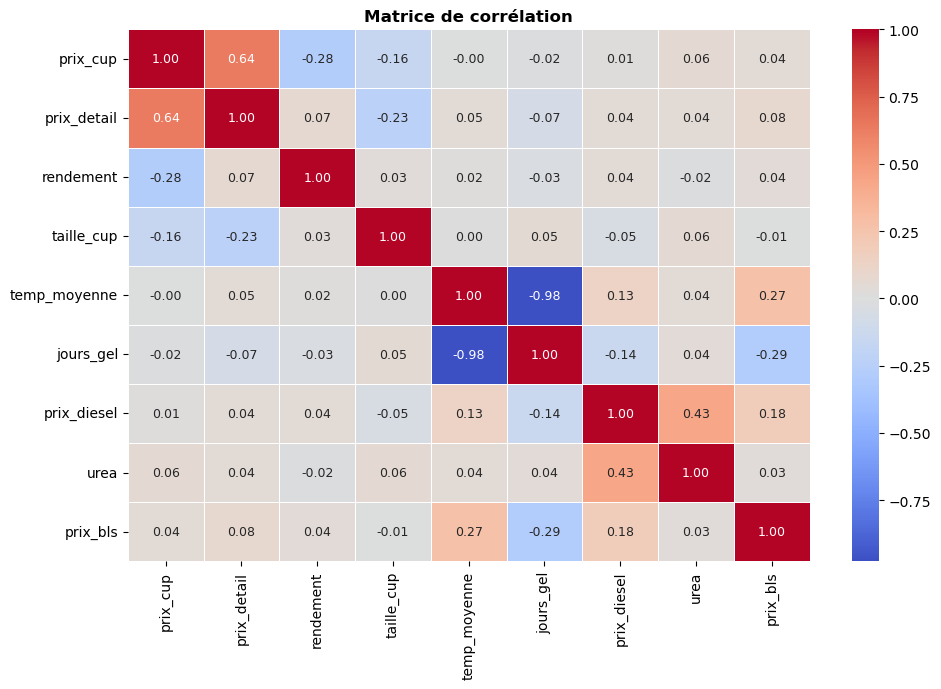

In [4]:
cols_corr = ['prix_cup', 'prix_detail', 'rendement', 'taille_cup',
             'temp_moyenne', 'jours_gel', 'prix_diesel', 'urea', 'prix_bls']

plt.figure(figsize=(10, 7))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Matrice de corrélation', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Prix par forme et par catégorie

**Interprétation** : La forme du produit influence significativement le prix par cup.
Le jus est le moins cher et la conserve est la plus chère — surprenant mais
s'explique par la surreprésentation des cerises en conserve dans le dataset.
Les fruits sont en moyenne légèrement plus chers que les légumes par cup.

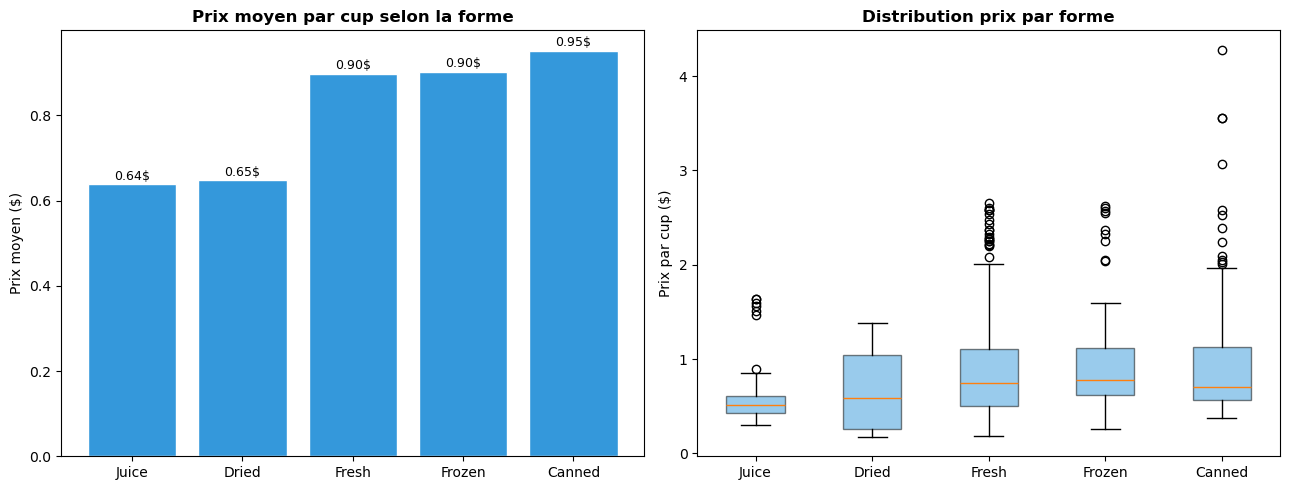

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Prix moyen par forme
moy_forme = df.groupby('forme')['prix_cup'].mean().sort_values()
axes[0].bar(moy_forme.index, moy_forme.values, color=BLEU, edgecolor='white')
axes[0].set_title('Prix moyen par cup selon la forme', fontweight='bold')
axes[0].set_ylabel('Prix moyen ($)')
for i, v in enumerate(moy_forme.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}$', ha='center', fontsize=9)

# Box plot par forme
formes = list(moy_forme.index)
data   = [df[df['forme'] == f]['prix_cup'].values for f in formes]
axes[1].boxplot(data, labels=formes, patch_artist=True,
                boxprops=dict(facecolor=BLEU, alpha=0.5))
axes[1].set_title('Distribution prix par forme', fontweight='bold')
axes[1].set_ylabel('Prix par cup ($)')

plt.tight_layout()
plt.show()

---
## 5. Évolution du prix par année

**Interprétation** : Le prix augmente régulièrement entre 2013 et 2023 — c'est
l'inflation alimentaire. La hausse est plus marquée pour les fruits que pour les légumes.
Le pic de 2022 correspond à la crise des engrais et à l'inflation post-Covid.
Cette tendance temporelle justifie l'ajout de `annee` comme feature dans le modèle.

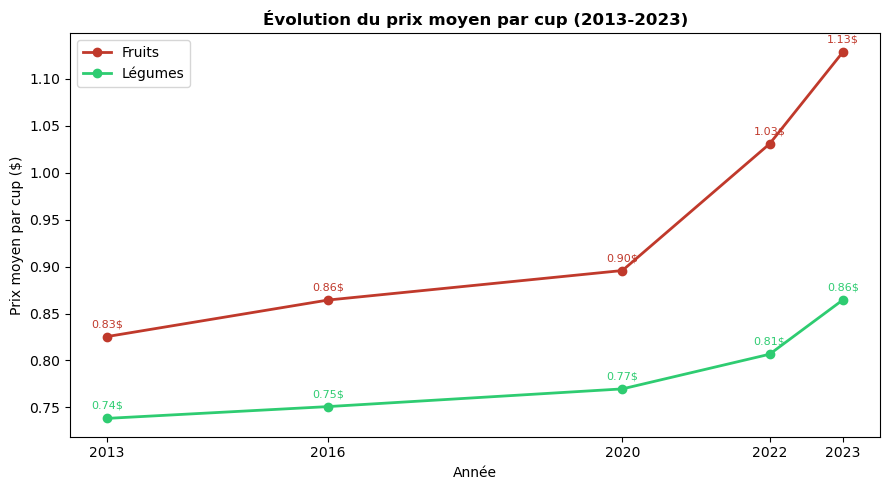

In [6]:
prix_annee = df.groupby(['annee', 'categorie'])['prix_cup'].mean().unstack()

plt.figure(figsize=(9, 5))
plt.plot(prix_annee.index, prix_annee['fruit'],
         color=ROUGE, marker='o', linewidth=2, label='Fruits')
plt.plot(prix_annee.index, prix_annee['legume'],
         color=VERT, marker='o', linewidth=2, label='Légumes')

# Annotation de la hausse
for cat, col in [('fruit', ROUGE), ('legume', VERT)]:
    vals = prix_annee[cat]
    for x, y in zip(prix_annee.index, vals):
        plt.text(x, y + 0.01, f'{y:.2f}$', ha='center', fontsize=8, color=col)

plt.title('Évolution du prix moyen par cup (2013-2023)', fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Prix moyen par cup ($)')
plt.xticks(prix_annee.index)
plt.legend()
plt.tight_layout()
plt.show()

---
## 6. Prix vs features clés (scatter plots)

**Interprétation** :
- `prix_detail` vs `prix_cup` : relation linéaire claire — confirme que c'est la meilleure feature.
- `rendement` vs `prix_cup` : relation négative — plus le rendement est bas, plus le prix par cup est élevé.
- `temp_moyenne` vs `prix_cup` : pas de relation linéaire claire — la météo agit de façon non-linéaire.
- `urea` vs `prix_cup` : légère tendance positive — quand les engrais coûtent cher, les prix alimentaires montent.

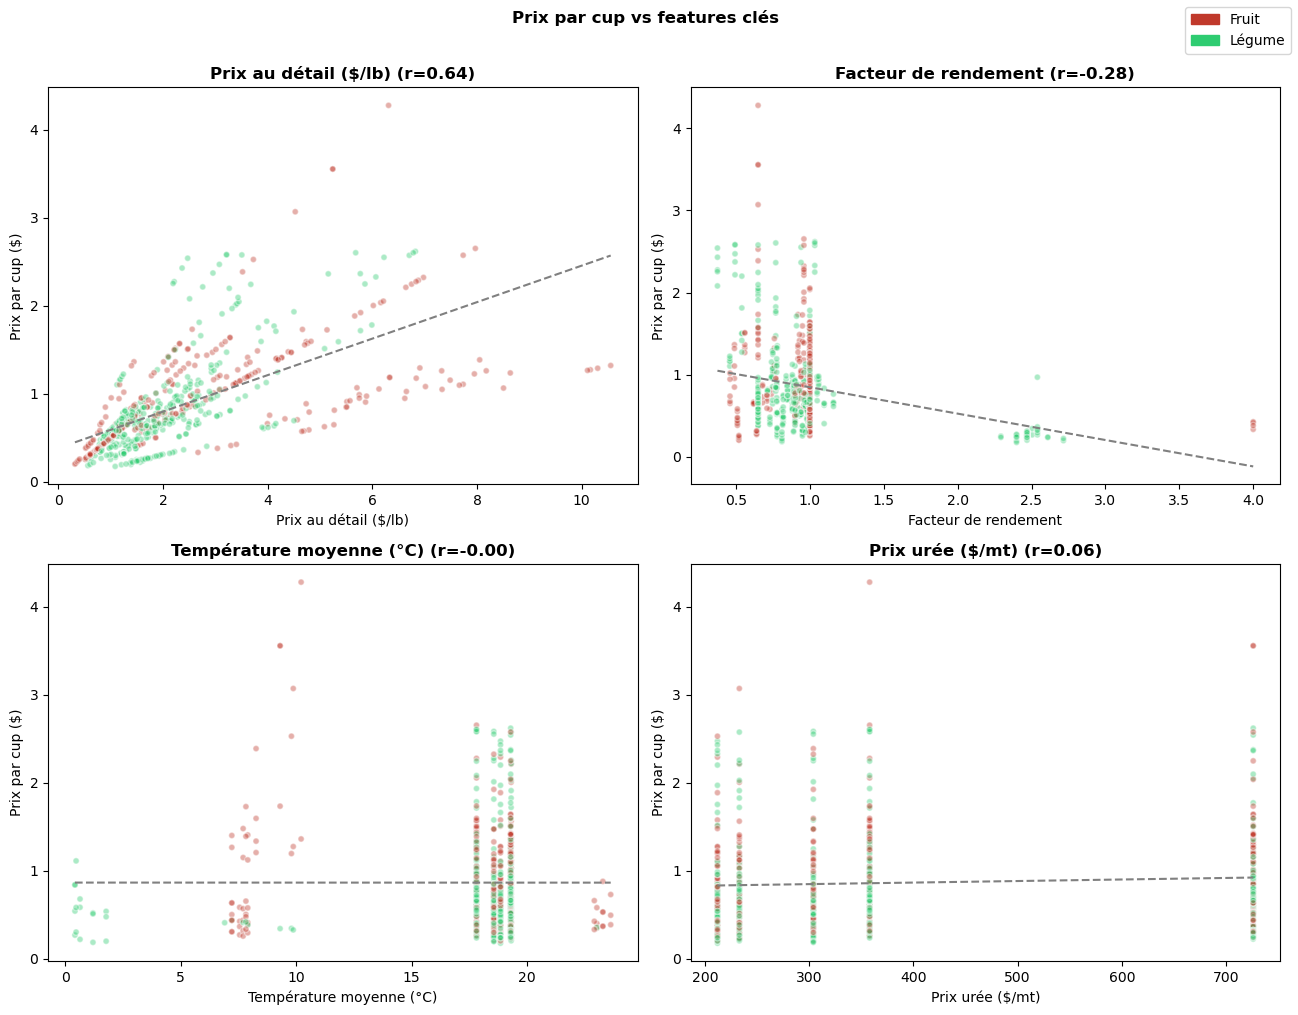

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

features = [
    ('prix_detail',  'Prix au détail ($/lb)'),
    ('rendement',    'Facteur de rendement'),
    ('temp_moyenne', 'Température moyenne (°C)'),
    ('urea',         'Prix urée ($/mt)'),
]

for i, (col, label) in enumerate(features):
    couleurs = [ROUGE if c == 'fruit' else VERT for c in df['categorie']]
    axes[i].scatter(df[col], df['prix_cup'],
                    color=couleurs, alpha=0.4, edgecolors='white', s=20)

    # Ligne de tendance
    z = np.polyfit(df[col].fillna(df[col].median()), df['prix_cup'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='gray', linestyle='--', lw=1.5)

    corr = df[[col, 'prix_cup']].corr().iloc[0, 1]
    axes[i].set_title(f'{label} (r={corr:.2f})', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Prix par cup ($)')

import matplotlib.patches as mpatches
fig.legend(handles=[
    mpatches.Patch(color=ROUGE, label='Fruit'),
    mpatches.Patch(color=VERT,  label='Légume')
], loc='upper right')

plt.suptitle('Prix par cup vs features clés', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Impact des engrais sur le prix (par année)

**Interprétation** : On voit clairement que les années avec des prix d'engrais élevés
(2022 — pic post-Ukraine) correspondent aux prix alimentaires les plus hauts.
Le décalage temporel est visible : les prix alimentaires 2022 sont élevés
car les engrais 2021-2022 étaient très chers. C'est exactement l'hypothèse
du cahier des charges.

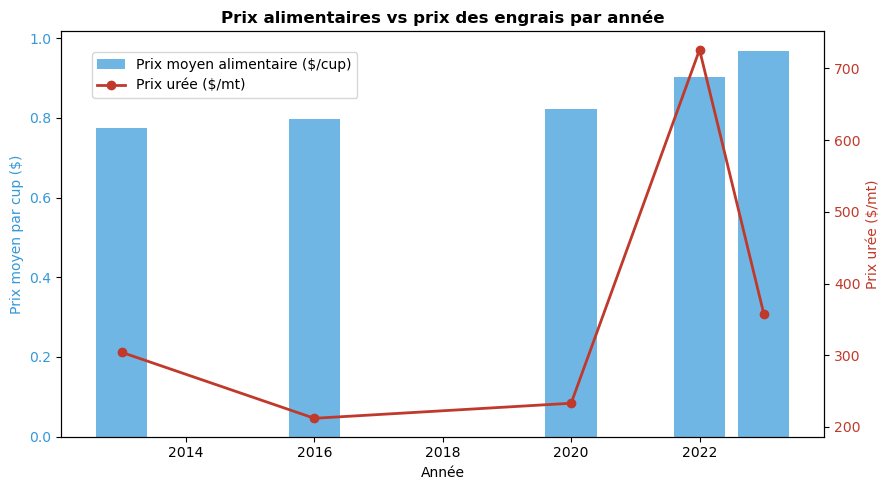

In [8]:
# Prix moyen urée et prix moyen alimentaire par année
resume = df.groupby('annee').agg(
    prix_cup_moy=('prix_cup', 'mean'),
    urea_moy=('urea', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 5))

# Axe gauche : prix alimentaire
ax1.bar(resume['annee'], resume['prix_cup_moy'],
        color=BLEU, alpha=0.7, label='Prix moyen alimentaire ($/cup)')
ax1.set_xlabel('Année')
ax1.set_ylabel('Prix moyen par cup ($)', color=BLEU)
ax1.tick_params(axis='y', labelcolor=BLEU)

# Axe droit : prix des engrais
ax2 = ax1.twinx()
ax2.plot(resume['annee'], resume['urea_moy'],
         color=ROUGE, marker='o', linewidth=2, label='Prix urée ($/mt)')
ax2.set_ylabel('Prix urée ($/mt)', color=ROUGE)
ax2.tick_params(axis='y', labelcolor=ROUGE)

plt.title('Prix alimentaires vs prix des engrais par année', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

---
## 8. Top produits les plus chers et les moins chers

**Interprétation** : Les produits séchés (mangues, abricots, raisins) dominent le top chers
car la déshydratation concentre le poids — il faut plus de matière pour remplir une cup.
Les produits les moins chers sont les légumes de grande production en conserve
(haricots, pois, maïs) — accessibles toute l'année et peu coûteux à produire.

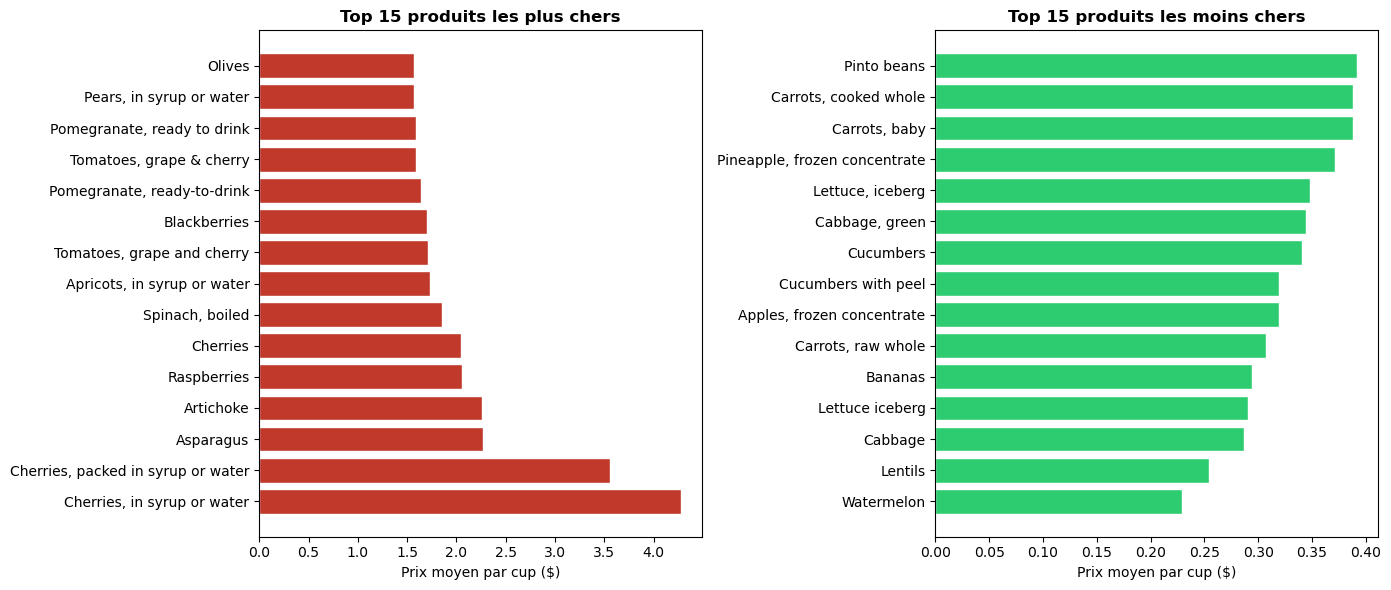

In [9]:
moy_produit = df.groupby('produit')['prix_cup'].mean()
top15  = moy_produit.nlargest(15).reset_index()
flop15 = moy_produit.nsmallest(15).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top15['produit'],  top15['prix_cup'],  color=ROUGE, edgecolor='white')
axes[0].set_title('Top 15 produits les plus chers',   fontweight='bold')
axes[0].set_xlabel('Prix moyen par cup ($)')

axes[1].barh(flop15['produit'], flop15['prix_cup'], color=VERT,  edgecolor='white')
axes[1].set_title('Top 15 produits les moins chers', fontweight='bold')
axes[1].set_xlabel('Prix moyen par cup ($)')

plt.tight_layout()
plt.show()

---
## 9. Pairplot des features clés

**Interprétation** : Le pairplot confirme que `prix_detail` est la variable la plus
linéairement liée à `prix_cup`. On observe deux nuages distincts fruits/légumes
principalement sur `prix_detail` et `rendement`. Les variables météo créent
des colonnes verticales car elles ont peu de valeurs uniques (une par état).

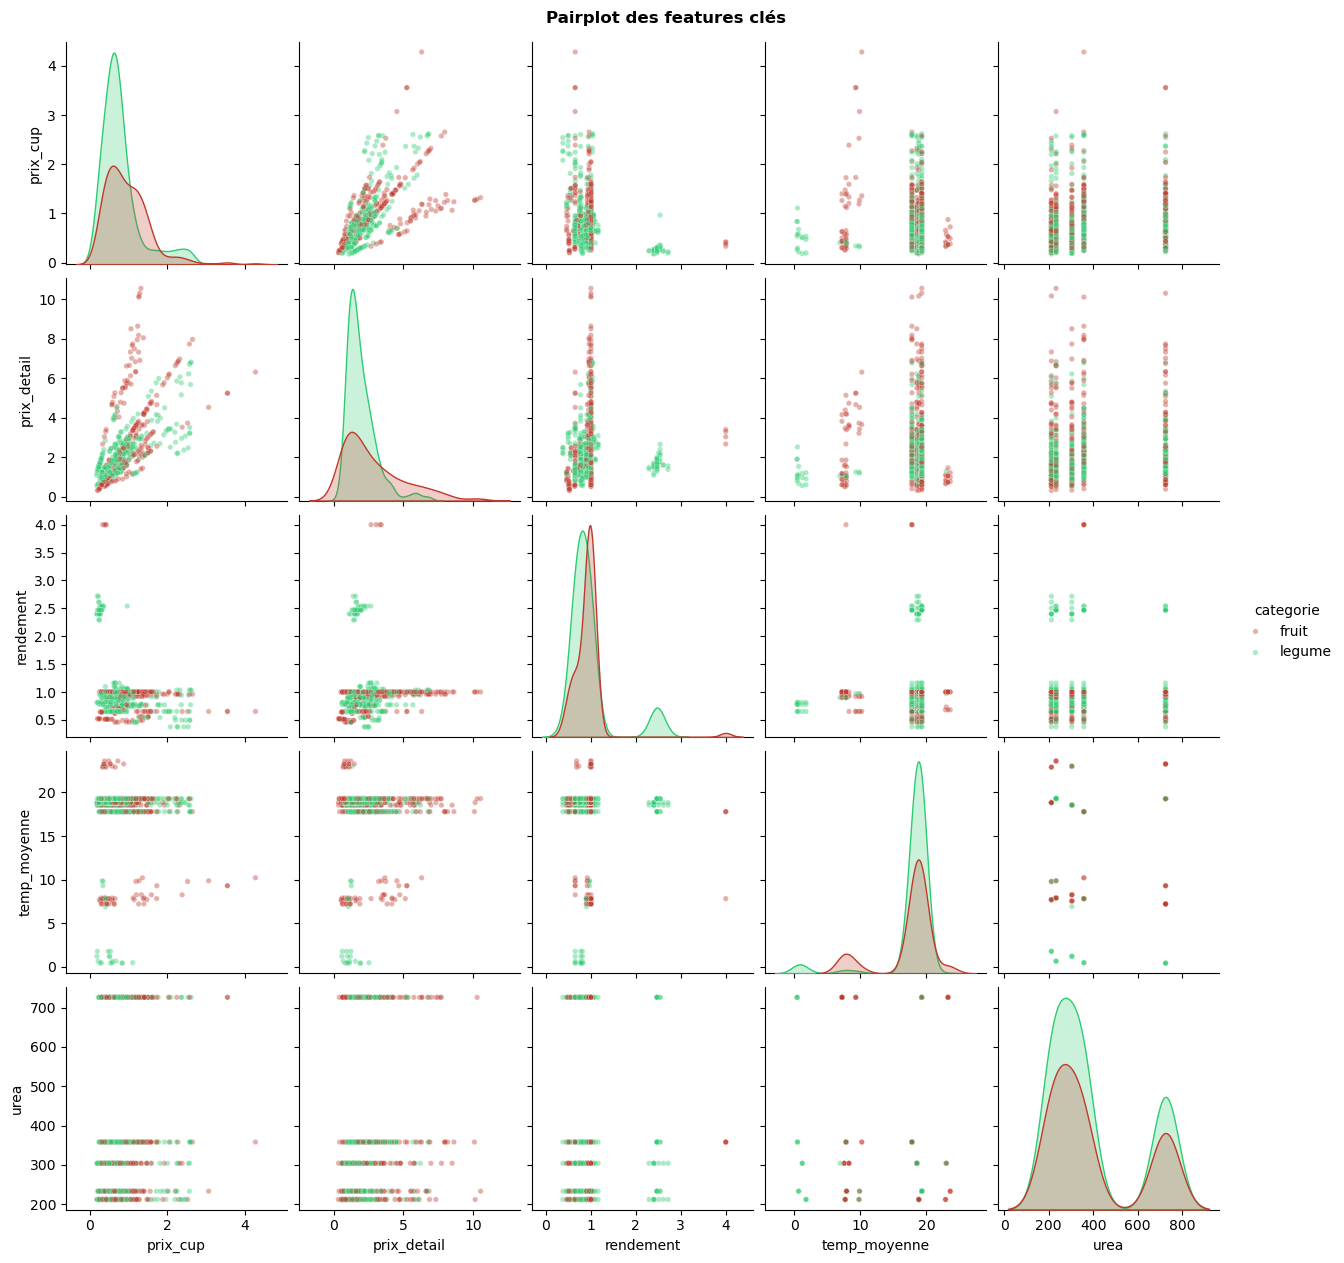

In [10]:
cols_pair = ['prix_cup', 'prix_detail', 'rendement', 'temp_moyenne', 'urea']

sns.pairplot(
    df[cols_pair + ['categorie']].dropna(),
    hue='categorie',
    palette={'fruit': ROUGE, 'legume': VERT},
    plot_kws={'alpha': 0.4, 's': 15}
)
plt.suptitle('Pairplot des features clés', fontweight='bold', y=1.01)
plt.show()

---
## Bilan EDA

**Features les plus importantes pour le modèle ML :**
1. `prix_detail` (r=0.64) — la feature principale
2. `rendement` (r=-0.28) — impact négatif logique
3. `forme_encoded` — la forme du produit change significativement le prix
4. `annee` — capture l'inflation temporelle
5. `urea` — proxy des coûts de production agricole

**Limites identifiées :**
- Les variables météo ont une faible corrélation linéaire mais peuvent
  apporter de la valeur dans un modèle non-linéaire (XGBoost, Random Forest)
- Les engrais (urea, dap, tsp, mop) sont très corrélés entre eux —
  on peut n'en garder qu'un seul (urea) pour éviter la multicolinéarité
- 520 lignes sans état producteur (produits importés) — la météo y est imputée
